## Explaining Differentiation

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (4, 3)

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

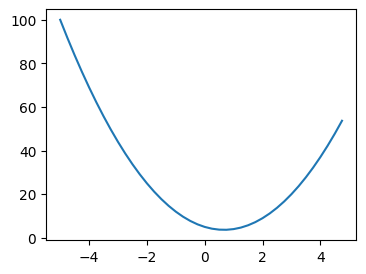

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.show()

In [5]:
### Differentiating
h = 0.000000001 #nudge function of x by a little
x = 3 # to see the slope of the function at point 3 of x axis
(f(x+h) - (f(x)))/h ## divide by h, to see slope rise/run or changes in y/ changes in x

14.000001158365194

In [6]:
h = 0.000000001 
x = 2/3
(f(x+h) - (f(x)))/h 

0.0

$\text{At point $\dfrac{2}{3}$ the derivative is 0, which means the slope is zero}$


In [7]:
a = 2
b = -3
c = 10
d= a*b + c
d

4

In [8]:
a = 2
b = -3
c = 10
d= a*b + c
d

4

In [9]:
h = 0.0001

#inputs
a = 2
b = -3
c = 10

d1 = a*b + c
a+=h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("slope" , f"{(d2-d1)/h:.2f}") 

d1 4
d2 3.999699999999999
slope -3.00


So increasing "a" will mean we will be going in the negative direction by slope of -3. 


and increasing "b" will mean we are going in the positive direction of slope 2. 


and "c" will just have a slope of 1. 

### Creating Class Value 
it should hold scaler values, plus implement all of their operations

In [10]:
class Value: 
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
    def __repr__(self): ## dunder function for representation
        return f"Value(data={self.data})"
    def __add__(self, other): 
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*')

In [11]:
a = Value(2)
b = Value(-3)

a,b

(Value(data=2), Value(data=-3))

In [12]:
a.__mul__(b) or a*b

Value(data=-6)

In [13]:
c = Value(10)
a.__mul__(b).__add__(c)

Value(data=4)

In [14]:
d = a*b + c
d._op

'+'

In [15]:
!pip install -Uq graphviz

In [16]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s |data %.2f }" % (n.label, n.data,),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this op node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


### Experiments to figure the tracing algorithm

In [17]:
def trace(root):
    nodes = set()
    edges = set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for parent in v._prev:
                edges.add((parent, v))
                build(parent)

    build(root)
    return nodes, edges

"""
so we build with v, v is ofcourse a node, because it is a number
if v is not then add it. 

then next, for their parents, add them as edges. 
"""

print()

In [18]:
aa = Value(1)
bb = Value(2)


In [19]:
cc = aa + bb

In [20]:
if cc._op: 
    print('true')

true


In [21]:
cc._op

'+'

In [22]:
nodes, edges = set(), set()

nodes, edges

(set(), set())

In [23]:
if cc not in nodes: 
    nodes.add(cc)

In [24]:
nodes

{Value(data=3)}

In [25]:
for parent in cc._prev: 
    edges.add((parent, cc))

In [26]:
edges

{(Value(data=1), Value(data=3)), (Value(data=2), Value(data=3))}

In [27]:
def trace(root_node): 
    nodes, edges = set(), set()
    
    def build(node): 
        if node not in nodes: 
            nodes.add(node)
            for parent in node._prev: 
                edges.add((parent, node))
                build(parent)
                
    build(root_node)
    return nodes, edges

    def draw_values_with_edges(nodes, edges): 
        dot = Digraph()
        for n in nodes: 
            uid = str(id(n))
            dot.node(uid, f"data = {n.data}")
        # Now we are looping over the edges, using the str id, we can create edge for each node
        for v1, v2 in edges: 
            dot.edge(str(id(v1)), str(id(v2)))
        
        return dot



In [28]:
dd = cc + Value(6)

In [29]:
nodes, edges = trace(cc)

nodes, edges

({Value(data=1), Value(data=2), Value(data=3)},
 {(Value(data=1), Value(data=3)), (Value(data=2), Value(data=3))})

In [30]:
for v1, v2 in edges: 
    print(v1, v2)

Value(data=1) Value(data=3)
Value(data=2) Value(data=3)


In [31]:
def draw_values_with_edges(expression): 
        nodes, edges = trace(expression)
        

        dot = Digraph(graph_attr={'rankdir': 'LR'})
        for n in nodes: 
            uid = str(id(n))
            dot.node(uid, f"data = {n.data}", shape='record')
            
            if n._op: # if it has an operater, then create a node operator and connected to the node
                # if 3, were the result of 1 plus 2, then make + --> 3. 
                opid = uid + str(id(n._op))
                dot.node(opid, n._op)
                dot.edge(opid, uid)
            
            
        # Now we are looping over the edges, using the str id, we can create edge for each node
        for v1, v2 in edges: 
            dot.edge(str(id(v1)), str(id(v2)) + str(id(v2._op))) #connect each childeren to the operator.
            # and since we are looping in edges only, they are guranteed to have operators. 
        
        return dot


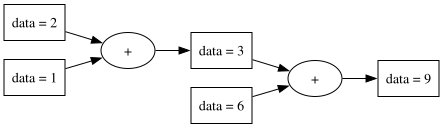

In [32]:
draw_values_with_edges(dd)

In [33]:
str(id(aa))

'4606173168'

In [34]:
str(id(aa)) + str(id(aa._op))

'46061731684303454256'

In [35]:
ddot = Digraph()

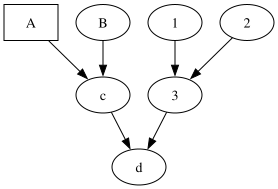

In [36]:
ddot.node('A', 'A', shape='record')
ddot.node('B', 'B')
ddot.edge('A', 'c')
ddot.edge('B', 'c')


ddot.node('1', '1')
ddot.node('2', '2')
ddot.edge('1', '3')
ddot.edge('2', '3')

ddot.edge('3', 'd')
ddot.edge('c', 'd')

ddot

### Continue

#### Add labels for class values

In [37]:
class Value: 
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self): ## dunder function for representation
        return f"Value(data={self.data})"
    def __add__(self, other): 
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*')

In [38]:
a = Value(2, label='a')
b = Value(-3, label='b')
c= Value(10, label='c')
e = a*b; e.label='e'
d = e + c; d.label= 'd'
f = Value(-2.0, label='f')
L = d * f; L.label='L'


In [39]:
trace(d)

({Value(data=-3),
  Value(data=-6),
  Value(data=10),
  Value(data=2),
  Value(data=4)},
 {(Value(data=-3), Value(data=-6)),
  (Value(data=-6), Value(data=4)),
  (Value(data=10), Value(data=4)),
  (Value(data=2), Value(data=-6))})

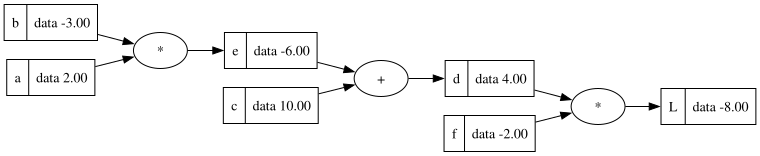

In [40]:
draw_dot(L)

## Adding Gradients 

In [41]:
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = grad #initially zero, since it has no affect on the function, either positive or negative. 
    def __repr__(self): 
        return f"Value(data={self.data})"
    def __add__(self, other): 
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*')

In [42]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s |data%.4f | grad=%.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this op node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [43]:
a = Value(2, label='a')
b = Value(-3, label='b')
c= Value(10, label='c')
e = a*b; e.label='e'
d = e + c; d.label= 'd'
f = Value(-2.0, label='f')
L = d * f; L.label='L'


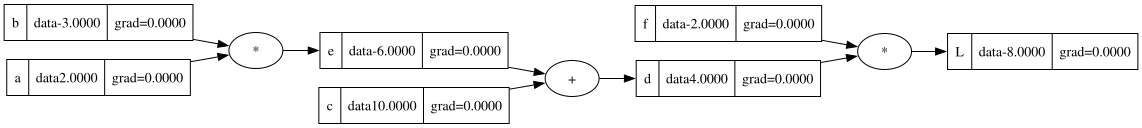

In [44]:
draw_dot(L)

In [45]:
L1 = L.data
L1

-8.0

In [46]:


def calc_grads(): 
    
    # do a local update, it is not going to update the global scope
    
    h = 0.001

    a = Value(2, label='a')
    b = Value(-3, label='b')
    c= Value(10, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label= 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

        
    for i in a, b, c, f:
        i.data += h
        
        e = a*b; e.label='e'
        d = e + c; d.label= 'd'
        f = Value(-2.0, label='f')
        L = d * f; L.label='L'
        L2 = L.data
        
        i.grad = (L2 - L1)/h
        i.data -= h
        
    L.grad = 1.0 # dl / dl = 1
    d.grad = f.data # dl / dd = f
    f.grad = d.data # dl/df = d
    
    e.grad = d.grad # chain rule 1*d.grad
    c.grad = d.grad # chain rule 1 * d.dgrad
    
        
    
    return draw_dot(L)
    
    
    

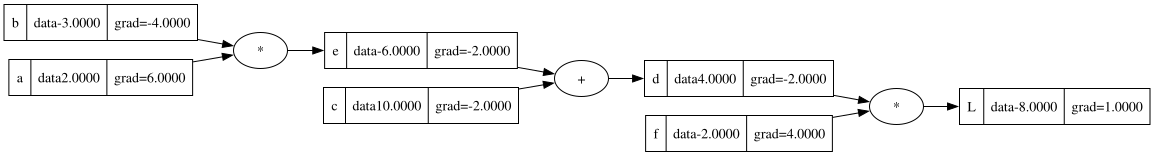

In [47]:
calc_grads()

<font size="4">
    It is fascinating how it gradients works in backpropagation, like any multiplication is just a scaler value 
    of the other $L = d \cdot f\text{ then the gradient of } \dfrac{\partial L}{\partial d} = f \text{ and gradient of }    \dfrac{\partial L}{\partial f} = d$
    However for the add it acts as a router especially for e and c, the gradient of d, is distributed among them since $d = e + c\ , \dfrac{\partial L}{\partial e} = \dfrac{\partial L}{\partial d} \cdot \dfrac{\partial d}{\partial e} \text{ and since } \dfrac{\partial d}{\partial e}=1, \text{we just get } d$
    
Same happens for $c$, $$\dfrac{\partial L}{\partial a} = b\ \cdot d\\$$
$$\dfrac{\partial L}{\partial b} = a\ \cdot d$$
    
so the $d = e + c$, is just a distribution of gradient of $d$ across $e$ and $c$, and $e$ pass it also to $a$ to be scaled by $b$, and $b$ to be scaled by $a$. 

It is very important to note that plus sign node in backpropgation is just a distribution of whatever the previous gradient were. This is how backpropgation works, plus node distributes and multiplication scales
   
</font>

In [48]:
# global update

a.grad = 6.00
b.grad = -4.00
e.grad = -2.00
c.grad = -2.00
d.grad = -2.00
f.grad = 4.00
L.grad = 1.00

<font size="4">Now we update the gradients </font>

In [49]:
lr = 0.01 # we update it by just a small scaler value. 

a.data += lr * a.grad
b.data += lr * b.grad
c.data += lr * c.grad
f.data += lr * f.grad


In [50]:
e = a*b
d = e + c
L = d*f

In [51]:
L

Value(data=-7.286496)

<font size = "4"> As you can see the value got bigger, the L value increased<br>
    since we went in the positive direction that will increase the function, this is called gradient ascent.<br><br>
It is tempting to think closer to zero is better, keep in mind this is not a loss function, that like MSE or MAE that would evaluate to zero, as it global minima, this is just a random multplication so our loss escape has no definition however lower is better, so -100, is better than -8, that is all we know </font>

## Small Neural Network

<font size="4">Now we add tanh activation function to the Value class </font>

In [52]:
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = grad 
    def __repr__(self): 
        return f"Value(data={self.data})"
    def __add__(self, other): 
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*')
    def tanh(self): 
        x = self.data
        tanh = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        return Value(tanh, (self, ), f'tanh({self.label})') # data: tanh, children: tuple(input), label: tanh 

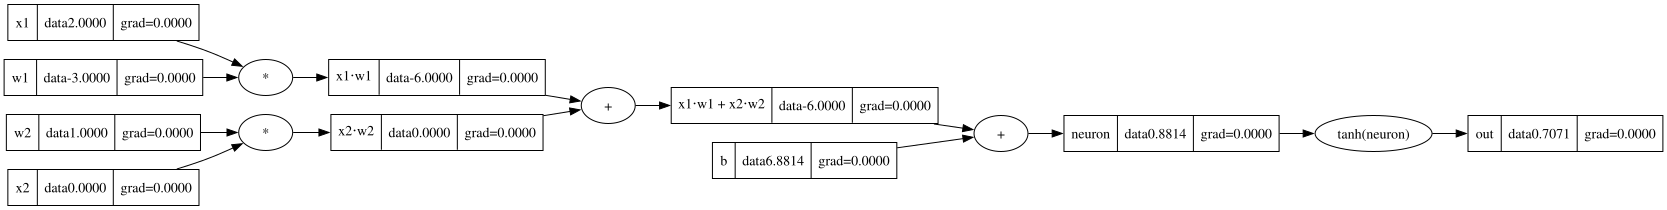

In [53]:
## inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

#weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

#bias
b = Value(6.8813735870195432, label="b")

##
x1w1 = x1*w1; x1w1.label= "x1⋅w1"
x2w2 = x2*w2; x2w2.label= "x2⋅w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1⋅w1 + x2⋅w2"
neuron = x1w1x2w2 + b; neuron.label = "neuron"
out = neuron.tanh(); out.label = "out"
dot = draw_dot(out)
dot

<font size="4"> Now you should look at the graph while we are backpropgating so you understand
    <br> $$tanh(n)' = 1-tanch(n)^{2}$$
</font>
        
        

In [54]:
#do/do = 1
out.grad = 1
neuron.grad = round(1-(out.data**2), 2) # 0.499 round to 0.5

<font size="4"> As we know that '+' node distributes gradient so b and (x1w1 + x2w1) --> This is a variable, 
    will get the neuron gradient<br><br> $$\dfrac{\partial out}{\partial b} = \dfrac{\partial out}{\partial neuron} \cdot
    \dfrac{\partial nueron}{\partial b}$$
    </font>

In [55]:
b.grad = 1* neuron.grad
x1w1x2w2.grad = 1*neuron.grad

x1w1x2w2 will distribute the gradient on x1w1 and x2w2 for the plus sign


In [56]:
x1w1.grad = 1*x1w1x2w2.grad
x2w2.grad = 1*x1w1x2w2.grad

<font size="4"> Know the 'x' node, so it should scale gradients of 0.5 for x1, w2 and x2, w2<br><br>
    As we know for $'x1w1' = w1 \cdot x1$<br>$\dfrac{\partial\  x1w1}{\partial\ x1} = w1 $ </font>

In [57]:
x1.grad = w1.data * x1w1.grad 
w1.grad = x1.data * x1w1.grad 


x2.grad = w2.data * x1w1.grad 
w2.grad = x2.data * x1w1.grad 


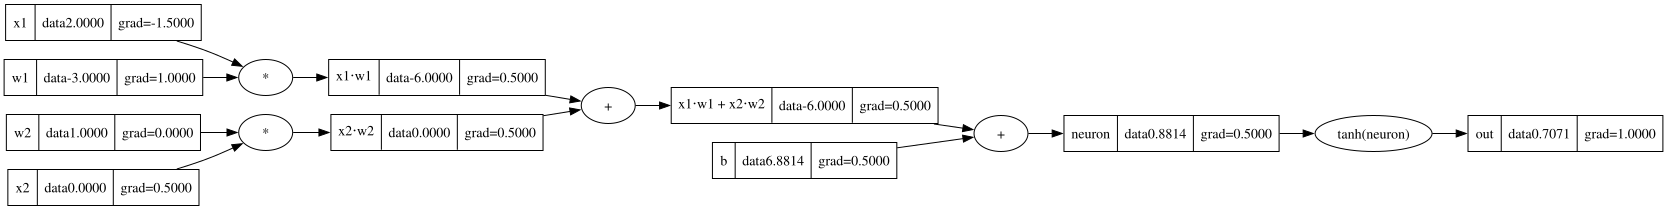

In [58]:
draw_dot(out)

<font size="4"> 'x1⋅w1' and 'x2⋅w2' both have 0.5 gradient which means the previous multiplication has positive gradient overall so<br> &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; x1, w1 and x2, w2 both have positive impact. <br><br>
  <b>  To analyze the situation further look at 'w2' gradient it have 0, the intuition behind is simple. <br>
The whole chain rule is about if we change w2 positively a little bit, how does that affect the output, i am speaking locally at the times node, so if we make w2 got bigger, still the output is unaffected because it is mutliplied by 0</font>
---
    

<font size="4">
  <b>  Let's look deeper at the '×'  '+' nodes<br> times node always scales the output so it is affect on the output (gradient) is obvious what ever it was multplied by because if (x + ∈)w, the increasing ∈ is mutiplied by w, that is the increasing value. <br>
However the plus is different it doesn't do anything it just combines whatever was coming, so it is affect by 1, proportional to the input if input increased by ∈ then it is gonna increase by that ∈, so it is gradient is just 1. 
</font>

## Automatic Differentiation

In [59]:
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None # Will explain later why we have this. 
        self.label = label
        self.grad = grad 
    def __repr__(self): 
        return f"Value(data={self.data})"
    def __add__(self, other): 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): 
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
            return
        out._backward = _backward # function is not called
        return out
        
    def __mul__(self, other): 
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward(): 
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
            return 
        out._backward = _backward # function is not called
        return out
            
    def tanh(self): 
        x = self.data
        tanh = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(tanh, (self, ), f'tanh({self.label})') 
        def _backward(): 
            self.grad = out.grad * (1-tanh**2)
            return
        out._backward = _backward # function is not called
        return out

<font size = "4"> The whole idea is that in either addition or multiplication we save the gradients for the future use. So each node that was produced from an operation ('+' or 'x') is saving their parents nodes, so it can be pass the gradient through them, and if node has lambda: None, that means if we call the function on it will do nothing instead of an error, that is why we put lambda: None there</font>

In [60]:
## inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

#weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

#bias
b = Value(6.8813735870195432, label="b")

##
x1w1 = x1*w1; x1w1.label= "x1⋅w1"
x2w2 = x2*w2; x2w2.label= "x2⋅w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1⋅w1 + x2⋅w2"
neuron = x1w1x2w2 + b; neuron.label = "neuron"
out = neuron.tanh(); out.label = "out"

We start by the first node out to have grad one, so we can callbackwards on the parents nodes. 

In [61]:
"""
We start from end, that is why we set out grad to be one, because when it is giving it is parent the gradient 
it can pass it through and not multipliy by the initlization of gradient which is zero. 
The whole idea of backward each output node, have it is parent gradient in it it self, and can only be called
in the future, only when it is child node called backward. 
"""
out.grad = 1
out._backward() 
neuron._backward()
b._backward() # b has no parents, it will not give error due to the initalization of lambda: None
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

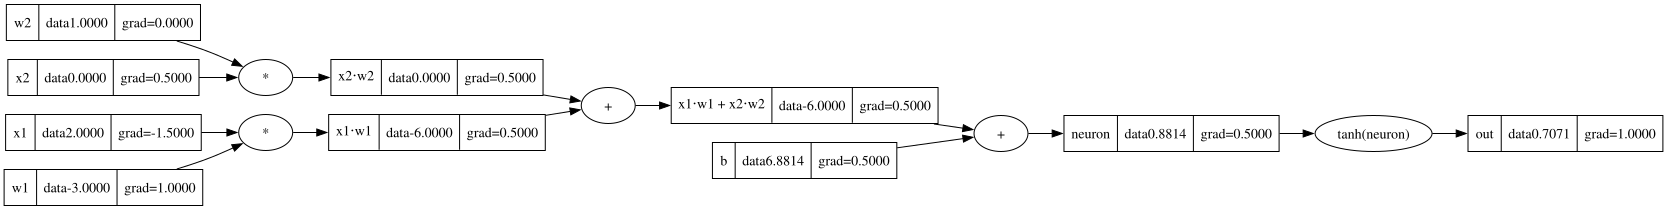

In [62]:
draw_dot(out)

<font size="4"><b>Works perfectly, NOW!! we implement it without using a loop <br> 
    Using Topological Sort On a DAG (Directed Graph)</font>

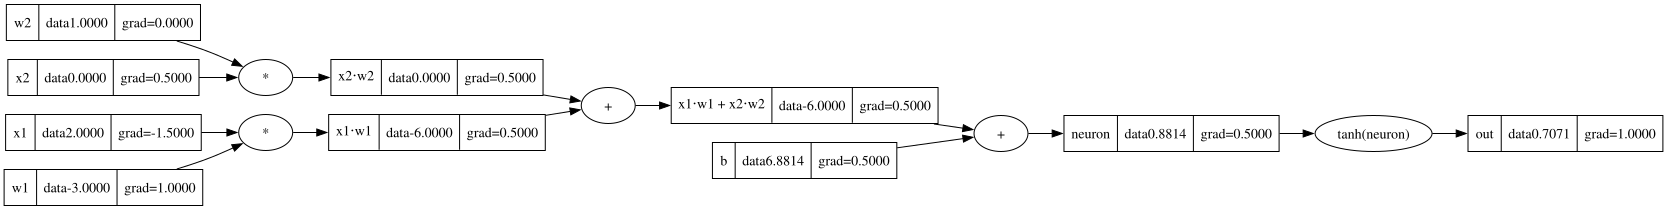

In [63]:
# topological order all of the children in the graph
out.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(out) # We start at the last node


for n in reversed(topo): # we do it backwards
    n._backward()
    
draw_dot(out)

<font size="4"><b>Now we hide it inside the class</font>

In [64]:
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None # Will explain later why we have this. 
        self.label = label
        self.grad = grad 
    def __repr__(self): 
        return f"Value(data={self.data})"
    def __add__(self, other): 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): 
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            return
        out._backward = _backward # function is not called
        return out
        
    def __mul__(self, other): 
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward(): 
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            return 
        out._backward = _backward # function is not called
        return out
            
    def tanh(self): 
        x = self.data
        tanh = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(tanh, (self, ), f'tanh({self.label})') 
        def _backward(): 
            self.grad += out.grad * (1-tanh**2)
            return
        out._backward = _backward # function is not called
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # We start at the last node

        self.grad = 1.0
        for n in reversed(topo): # we do it backwards
            n._backward()
        return 
     

In [65]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1*w1; x1w1.label= "x1⋅w1"
x2w2 = x2*w2; x2w2.label= "x2⋅w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1⋅w1 + x2⋅w2"
neuron = x1w1x2w2 + b; neuron.label = "neuron"
out = neuron.tanh(); out.label = "out"

In [66]:
out.backward()

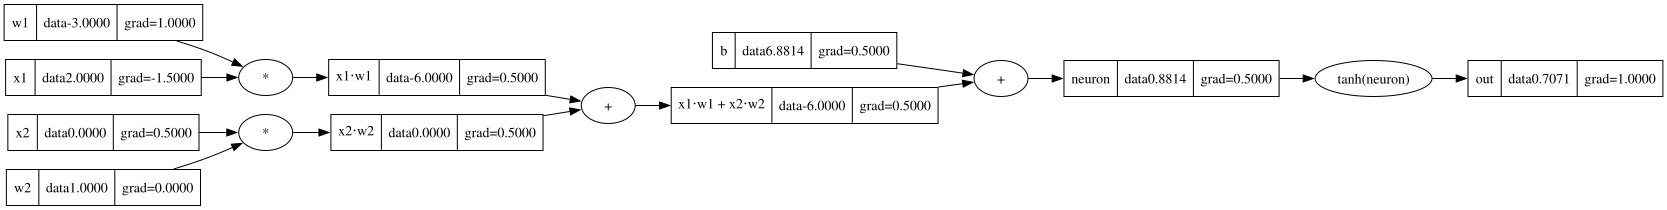

In [67]:
draw_dot(out)

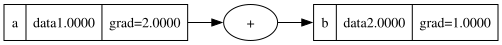

In [68]:
a = Value(1, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)


<font size = "4">Because the variable 'a' is used more than once, based on multivariable calculus calculus we have to accumulate the gradient 
that is why in the Value class I changed assign of grad from '=' to '+=' <br> <br>
You can https://www.youtube.com/watch?v=VMj-3S1tku0&t=4801s as 1:23, one hour, 23 minutes, to 
have more understanding why it can make a problem <br> <br>
The above example 'a' is used twice and it should have gradient of 2, however if no += were added it would've been set to one, 
because previously gradient were set with '=', so it would've overwritten the previous gradient, however '+=' would
accumulate it</font>

##  Making the Value Class more robust

In [69]:
"""
a + 2
b * 2

Done by __rmul__ and __radd__ reversed add or reversed multiplication 
2 + a
2 * b

all these operations are not supported so we add if other is not of Value class make it one
and add __rmul__ so if other * self doesn't work it tries selt * word 
"""
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None # Will explain later why we have this. 
        self.label = label
        self.grad = grad 
    def __repr__(self): 
        return f"Value(data={self.data})"
    
    def __add__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): 
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            return
        out._backward = _backward # function is not called
        return out
        
    def __mul__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward(): 
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            return 
        out._backward = _backward # function is not called
        return out
    
    def __rmul__(self, other): # other * self
        return  self * other
    
    def __radd__(self, other): # other + self
        return  self * other
            
    def tanh(self): 
        x = self.data
        tanh = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(tanh, (self, ), f'tanh({self.label})') 
        def _backward(): 
            self.grad += out.grad * (1-tanh**2)
            return
        out._backward = _backward # function is not called
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # We start at the last node

        self.grad = 1.0
        for n in reversed(topo): # we do it backwards
            n._backward()
        return 
     

In [70]:
a = Value(2)
b = Value(6)
a + 2
b * 2
2 + a
2 * b

Value(data=12)

### Add Division, Subtraction, Power, exponents(e)

In [71]:
"""
a + 2
b * 2

Done by __rmul__ and __radd__ reversed add or reversed multiplication 
2 + a
2 * b

all these operations are not supported so we add if other is not of Value class make it one
and add __rmul__ so if other * self doesn't work it tries selt * word 

------------------------------------------------------------------------

Also we add --> We add __pow__ and use it it inside the __truediv__
a / b = a*(1/b)
a / b = a * (b**-1)

So we implement the division using the power way. 


------------------------------------------------------------------------

Subtraction --> addition of negative, we implement __neg__ and __sub__
a - b = a + (-b)


"""
class Value: 
    def __init__(self, data, _children=(), _op='', label='', grad=0.0):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None # Will explain later why we have this. 
        self.label = label
        self.grad = grad 
    def __repr__(self): 
        return f"Value(data={self.data})"
    
    def __add__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): 
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            return
        out._backward = _backward # function is not called
        return out
    
    def __neg__(self): 
        return self * -1 
        # Will call self.__mul__(-1) !!!SAVES gragient in mul fo backprop if self instance of Value
    
    def __sub__(self, other): 
        return self + (-other) # --> self.__add__(other.__neg__(-1)) !!!SAVES gradient in add for backprop
     
    def __mul__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward(): 
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            return 
        out._backward = _backward # function is not called
        return out
    
    def __rmul__(self, other): # other * self
        return  self * other
    
    def __radd__(self, other): # other + self
        return  self + other        
        
    def __pow__(self, other): #self is a Value and other is power. 
        assert isinstance(other, (int, float)) # power should be int or float
        out = Value(self.data ** other, (self, ), _op=f"**{other}", label=f"{self.label}{other}")
        
        def _backward(): 
            self.grad += ( other * (self.data ** (other-1)) )  * out.grad# d/dx x^n = nx^n-1 (self = x, other = n) * prev grad
            return 
        out._backward = _backward
        
        return out
    
    def __truediv__(self, other): 
        return self * other**-1 # this would call __pow__     
    
            
    def tanh(self): 
        x = self.data
        tanh = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(tanh, (self, ), f'tanh({self.label})') 
        def _backward(): 
            self.grad += out.grad * (1-tanh**2)
            return
        out._backward = _backward # function is not called
        return out
    
    def exp(self): 
        x = self.data 
        out = Value(math.exp(x), (self, ), _op="exp", label=f"{self.label}e")
        def _backward():
            self.grad += out.data * out.grad # the exponent of e^x is e^x,* out.grad for chain rule
            return 
        out._backward = _backward
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # We start at the last node

        self.grad = 1.0
        for n in reversed(topo): # we do it backwards
            n._backward()
        return 
     

In [72]:
a = Value(3)
b = Value(4)

a/b

Value(data=0.75)

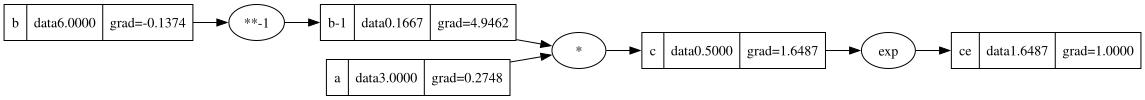

In [73]:
a = Value(3.0, label='a')
b = Value(6.0, label='b')
c = a / b; c.label = 'c'
d = c.exp();
d.backward()
draw_dot(d)

In [74]:
y = Value(10)
y - 5 # It will self + (-5) and __add__ will turn the second operation to Value

Value(data=5)

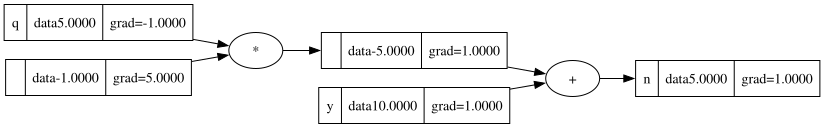

In [75]:
y = Value(10, label='y')
q = Value(5, label='q')

n = y - q; n.label = 'n'

n.backward()
draw_dot(n)

### Torch Implementation 

In [76]:
import torch

In [77]:
x1 = torch.Tensor([2.0]).double()                 ;x1.requires_grad=True # to track gradients for backpropgation
x2 = torch.Tensor([0.0]).double()                 ;x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double()                ;w1.requires_grad=True
w2 = torch.Tensor([1.0]).double()                 ;w2.requires_grad=True
b = torch.Tensor([6.8813735870195432]).double()   ;b.requires_grad=True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# o is forward pass
print(o.item()) # item() just strips the number from a tensor and return it
o.backward() # same as micrograd, same functionality and code, except it is more efficent and deals with tensors

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [78]:
import sys
sys.float_info.mant_dig # python uses 64 bit for floating point equivalent for double() in torch

53

In [79]:
torch.Tensor([3.0]).dtype #default

torch.float32

In [80]:
torch.Tensor([3.0]).double().dtype # same as python

torch.float64

In [81]:
import sys
sys.float_info.dig # 15 decimal accuracy

15

<font size = '4'> <b> float 64: which is about 15 decimal digit<br>
float 32: is about 7 decimal accuracy</font>

## Neural Network

### Single Neuron 

In [82]:
import random

In [83]:
class Neuron: 
    def __init__(self, nin): 
        self.w = [Value(random.uniform(-1, 1), label=f"w{_}") for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')
            
    def __call__(self, x): # x --> inputs must be same size as w to do dot product
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) # w⋅x + b 
        out = act.tanh()
        return out
        

In [84]:
x=[2, 3] #inputs
nn = Neuron(2)# size two
nn.w, nn.b

([Value(data=-0.819345642272987), Value(data=0.6542544020032868)],
 Value(data=-0.10937570488166504))

In [85]:
out = nn(x) # same as nn.__call__(x)

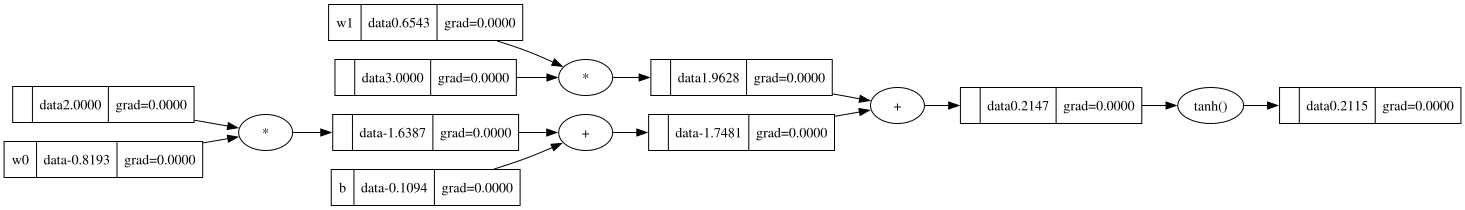

In [86]:
draw_dot(out)

### Multilayer Perceptron (MLP)

In [87]:
class Layer:
    def __init__(self, nin, nout): # dimensions (input, output)
        self.neurons = [Neuron(nin) for _ in range(nout)]
        self.nin = nin
        self.nout = nout
    
    def __call__(self, x): 
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs # Because it output is single scaler we return it
    
    def __repr__(self):
        return f"Layer(nin={self.nin}, nout={self.nout})"
    
inputs = [1.5, 3.3] # input is two 
l1 = Layer(2, 3) # must match input and output is any arbitrary number you want
output = l1(x)
output

[Value(data=0.9991330289004947),
 Value(data=-0.9572401761579319),
 Value(data=-0.9932549259240014)]

<font size='4'> A layer is multiple neurons, and a neuron takes multiple inputs or one inputs and produce a scaler<br> Layer(2, 3) Means we have two inputs for each neuron out of the 3 total neurons, and neuron produce 
    a single scaler, so we have 3 scalers values, each one is sum product of $$\sum_{i=1}^{n} w_{i} \cdot x_{i} + b\text{ where $n$ is number of inputs}$$
That means if we have input of 100 then each neuron will contain 100 weights with one bias, input match weights<br>
and output is how many scalers values out of these 100 summation of products we get, in simple terms the output is <br> <br> $$
\text{output} =
\begin{bmatrix}
\sum_{i=1}^{n} x_i w_{1i} + b_1 \\
\sum_{i=1}^{n} x_i w_{2i} + b_2 \\
\vdots \\
\sum_{i=1}^{n} x_i w_{ki} + b_k
\end{bmatrix}
$$ <br>
    Output just says how many times we will do these multiplication  And of course weights are initialized randomly between -1 and 1, so we would have different values for each input<br>
 And that is one layer my friend<br><br><br>
    Multiple layers means we have 3 scaler values from output from Layer1, these 3 go into each neuron of the 2nd layer
    so the input of second layer must match the output of the previous layer, assume we have 2nd layer of (3, 2), that means we have 3 output scaler from the 1st layer, then these $(3 * w0,w1,w2 +b ) \text{ will happen two times}$ <br>
    these 3 will be multiplied 2 times, into 3 randomly initialized w's + b for each neuron <br> <br>
    If you think about it each neuron just condense information of inputs in itself, $inputs\cdot w's$ in one neuron, and 2nd layer take all the previous outputs and condense them again, like 1st neuron of the 2nd layers, contain 3 previous neurons condensed information and condense them again into single a output, like as we increase the layer, each neuron will contain all multiplications of the previous operations for each neurons of the previous layers, which is wild. So as layers increase each neuron information is much more heavy than the previous, until the most important one which is output neuron if regression, which will have all previous operations inside it
    </font>    

In [88]:
class MLP: 
    def __init__(self, nin, nouts): 
        self.sz = [nin] + nouts
    
    def get(self): 
        return self.sz
        
        
mlp = MLP(2, [3, 2]).get() # second define each layer
mlp

[2, 3, 2]

In [89]:
lls = [Layer(mlp[i], mlp[i+1])for i in range(2)]

In [90]:
lls 

[Layer(nin=2, nout=3), Layer(nin=3, nout=2)]

<font size='4'> As you can see we take (2,3), then (3,2) so output of previous layer match input of the second layer</font>

In [91]:
inputs = [1.5, 3.3] 
l1 = Layer(2, 3) 
l2 = Layer(3, 2)
l3 = Layer(2, 1)
output = l1(inputs)
output    

[Value(data=0.8470867529133762),
 Value(data=0.9619788204214414),
 Value(data=-0.9522245881663077)]

In [92]:
output = l2(output)
output

[Value(data=0.9539707506421976), Value(data=-0.9297097755702488)]

In [93]:
output = l3(output)
output

Value(data=0.6347975327689357)

In [94]:
x = [1.5, 3.3]
for layer in l1,l2,l3: 
    x = layer(x)
x

Value(data=0.6347975327689357)

<font size='4'> As you can a forward pass is just a for loop of Layer(input=previous_layer_output)</font>

In [95]:
class MLP: 
    def __init__(self, nin, nouts): 
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x): # x is the input data
        for layer in self.layers: 
            x = layer(x)
        return x 

In [96]:
x = [2.0, -3.4, 0.5] 
mlp = MLP(3, [4, 4, 1])
fpass = mlp(x)
fpass.backward()

## Loss Function 

### Mean Square Error

In [97]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5], 
    [0.5, 1.0, 1.0], 
    [1.0, 1.0, -1.0]
]
print(f"shape({len(xs)},{len(xs[0])})")

shape(4,3)


In [98]:
ys = [1.0, -1.0, -1.0, 1.0] #desired output
ys 

[1.0, -1.0, -1.0, 1.0]

<font size='4'>Each row of xs, should predict in <b>order</b> each value of ys</font>

In [99]:
mlp = MLP(3, [4, 4, 1])
ypreds = [mlp(x) for x in xs]
ypreds

[Value(data=-0.941425380395671),
 Value(data=0.10140413958894656),
 Value(data=-0.32481135515830756),
 Value(data=-0.6944157299989497)]

<font size='4'>Now we implement Mean Square Error $$MSE = \dfrac{1}{n}\sum_{i=1}^{n} (y_{i} - \hat{y}_{i})^{2}$$<br> It is just difference squared between real value and predicted value.The reason square we is to always get a positive number, so it doesn't matter if the difference is positive or negative, we could use absolute or square both work just fine. We want to have difference of zero, that means the predicted value same as real value, so our goal is to minimize the loss, make it as small as possible preferably zero</font>

In [100]:
[(yhat - y)**2 for y, yhat in zip(ys, ypreds)]

[Value(data=3.7691325076444766),
 Value(data=1.213091078703668),
 Value(data=0.45587970612316103),
 Value(data=2.8710446660678737)]

In [101]:
loss = sum([(yhat - y)**2 for y, yhat in zip(ys, ypreds)])
loss.backward()

<font size='4'>Avoid this, if you are new to neural networks, but this essentially Batch Gradient Descent We accumulate gradient, since the update of gradient is "+=" so the gradient is accumulated for all these 4
samples<br> If it were Stochastic Gradient Descent: 
```python 
 for x, y in zip(xs, ys):
    yhat = mlp(x)
    loss = (yhat - y)**2
    loss.backward()
    update_params()
    zero_grads()
``` 
</font>
<font size='4'> If it were SGD it would do it per row</font>

## Gradient Descent

<span style="color: red;"><b>Note: Inputs xs, are not to be updates this the input data, we don't want to change it, our interest is in the parameters the weights and biases</span>


In [102]:
class Neuron: 
    def __init__(self, nin): 
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
            
    def __call__(self, x): 
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) 
        out = act.tanh()
        return out
        
    def parameters(self): 
        return self.w + [self.b]
    
    
class Layer:
    def __init__(self, nin, nout): 
        self.neurons = [Neuron(nin) for _ in range(nout)]
        self.nin = nin
        self.nout = nout
    
    def __call__(self, x): 
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs 
    
    def parameters(self): 
        return [ps for neuron in self.neurons for ps in neuron.parameters()]
    
    def __repr__(self):
        return f"Layer({self.nin}, {self.nout})"
    
    
class MLP: 
    def __init__(self, nin, nouts): 
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x): # x is the input data
        for layer in self.layers: 
            x = layer(x)
        return x 
    
    def parameters(self): 
        return [p for layer in self.layers for p in layer.parameters()]
    

In [103]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5], 
    [0.5, 1.0, 1.0], 
    [1.0, 1.0, -1.0]
]
print(f"Input shape:({len(xs)},{len(xs[0])})")

mlp = MLP(3, [4, 4, 1])
ypreds = [mlp(x) for x in xs]


loss = sum([(yhat - y)**2 for y, yhat in zip(ys, ypreds)])
loss.backward()
loss

Input shape:(4,3)


Value(data=4.403039729349179)

In [104]:
for layer in mlp.layers: 
    print(layer)

Layer(3, 4)
Layer(4, 4)
Layer(4, 1)


<font size='4'>1st layer: $3 \cdot 4 = 12$<br>
    $12 + 4 (bias) = 16$<br><br>
2nd layer: is $4 \cdot 4 = 16$<br>
   $16 + 4 (bias) = 20$<br><br>
3rd layer: $4 + 1(bias) = 5$<br><br>
$Total = 16 + 20 + 5 = 41$<br>
  </font>


In [105]:
len(mlp.parameters())

41

In [106]:
mlp.parameters()[:3]

[Value(data=-0.30827712158504283),
 Value(data=0.1204840649417922),
 Value(data=-0.6440207119421626)]

In [107]:
print(mlp.parameters()[:3][0].grad)
print(mlp.parameters()[:3][1].grad)
print(mlp.parameters()[:3][2].grad)

0.5454187907104492
1.0684920744787043
-2.1697080480185478


In [108]:
lr = 0.01
for p in mlp.parameters():
    p.data -= 0.01 * p.grad

In [109]:
mlp.parameters()[:3]

[Value(data=-0.31373130949214734),
 Value(data=0.10979914419700516),
 Value(data=-0.6223236314619771)]

<font size='4'>As explained before we move into the negative direction of the gradient vector, because the gradient vector is pointing to increasing loss, because gradient tells is if nudge a little amount positive, what happens to ,so we move into the opposite of the slope, of each value, or in general term we go in the opposite direction of the gradient vector </font>

In [110]:
#previous loss
loss

Value(data=4.403039729349179)

In [111]:
# Another forward pass after we did gradient descent the loss should decrease, i.e move closer to zero
ypreds = [mlp(x) for x in xs]
loss = sum([(yhat - y)**2 for y, yhat in zip(ys, ypreds)])
loss

Value(data=3.782485087715165)

### Automate the forward pass and backward pass plus the update parameters

In [178]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5], 
    [0.5, 1.0, 1.0], 
    [1.0, 1.0, -1.0]
]
print(f"Input shape:({len(xs)},{len(xs[0])})")

ys = [1.0, -1.0, -1.0, 1.0]

mlp = MLP(3, [4, 4, 1])

Input shape:(4,3)


In [179]:
lr = 0.05
for e in range(20): # 20 Epochs
    
    # forward pass    
    ypreds = [mlp(x) for x in xs]
    loss = sum([(yhat - y)**2 for y, yhat in zip(ys, ypreds)])
    
    #backward pass
    loss.backward()
    
    for p in mlp.parameters():
        p.data -= 0.01 * p.grad
        p.grad = 0.0
    
    print(e, loss.data) #iteration and loss    

0 2.759092766232564
1 1.9096539385725217
2 1.3616591043283939
3 1.0487870834236372
4 0.8460371398319753
5 0.7006963734312592
6 0.5916471384779884
7 0.5077336186539897
8 0.44189973752565154
9 0.3893572056579543
10 0.34676106754755925
11 0.31173162934369425
12 0.2825486835395664
13 0.25794944986710205
14 0.23699297997091315
15 0.2189680177813001
16 0.20332958484825187
17 0.18965475291535897
18 0.17761138081286096
19 0.16693571952184172


In [180]:
ypreds

[Value(data=0.8074959126573901),
 Value(data=-0.7750272268603666),
 Value(data=-0.7447473924042108),
 Value(data=0.8812092026306597)]

<font size='4'>As you can we are very close the output targets, the loss is about one in 100,000 </font>

In [181]:
for pred in ypreds: 
    print(round(pred.data))

1
-1
-1
1


In [182]:
sample = [2.0, 3.0, -1.0] # this should have one output
sample

[2.0, 3.0, -1.0]

In [183]:
round(mlp(sample).data)

1